## Unsupervised ML : Anomaly detection

In [1]:
### autreloader
%load_ext autoreload
%autoreload 2

In [2]:
### setting up the system path
import sys
sys.path.append('../')

In [ ]:
### importing the functions from the src
from src.basic.basic_processing import load_data, check_nan_duplicates_shape
from src.unsupervised.pca import reduce_dimensions, check_shape
from src.unsupervised.anomaly import find_threshold, find_contamination, outliers_isolation_forest, outliers_lof, outliers_dbscan

##### *********** Train data *************

In [4]:
### loading up the data
train_path = '../data/unsupervised_ready/train.csv'
train = load_data(train_path)
train.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0.317272,0,0,0.307692,0.209694,1.00,0.592437,0.734863,0.366737,0,0.272727,0.400000,0.695652,0.424444
1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0.949384,0,0,0.538462,0.387653,0.25,0.130252,0.159358,0.486549,0,0.181818,0.866667,0.217391,0.577225
2,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0.390503,0,0,0.461538,0.458673,0.50,0.848739,0.457245,0.296030,1,0.727273,0.866667,1.000000,0.254520
3,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0.458690,0,0,0.538462,0.683633,0.50,0.571429,0.985009,0.336134,0,0.727273,0.300000,0.565217,0.490544
4,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0.525140,0,0,0.384615,0.911776,0.25,0.029412,0.984885,0.080308,0,0.000000,0.400000,0.260870,0.307802


In [5]:
### checking up the things
check_nan_duplicates_shape(train)

Shape : (40000, 33) 
Duplicates : 0 
Transaction_Type_Bank Transfer    0
Transaction_Type_Online           0
Transaction_Type_POS              0
Device_Type_Mobile                0
Device_Type_Tablet                0
Location_Mumbai                   0
Location_New York                 0
Location_Sydney                   0
Location_Tokyo                    0
Merchant_Category_Electronics     0
Merchant_Category_Groceries       0
Merchant_Category_Restaurants     0
Merchant_Category_Travel          0
Card_Type_Discover                0
Card_Type_Mastercard              0
Card_Type_Visa                    0
Authentication_Method_OTP         0
Authentication_Method_PIN         0
Authentication_Method_Password    0
Account_Balance                   0
IP_Address_Flag                   0
Previous_Fraudulent_Activity      0
Daily_Transaction_Count           0
Avg_Transaction_Amount_7d         0
Failed_Transaction_Count_7d       0
Card_Age                          0
Transaction_Distance       

In [15]:
### redcuing the data to 2 dimensions
train_pca = reduce_dimensions(train)
check_shape(train_pca)

(40000, 2)

##### 1. Isolation forest

[-0.68255511 -0.68071038 -0.68071038 ... -0.44036844 -0.43998876
 -0.43952571]


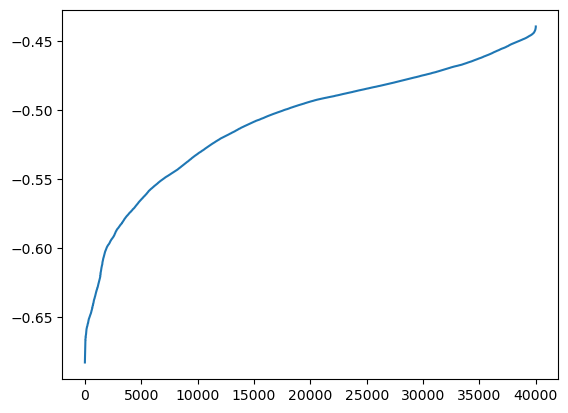

In [16]:
### finding the value of threshold
scores_train = find_threshold(train_pca)

In [17]:
### finding the contamination
find_contamination(train_pca, scores_train, threshold = -0.63)

1054
0.026349999999999985


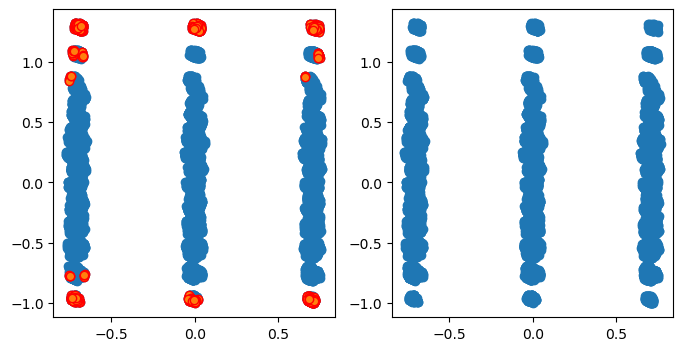

In [18]:
### taking contamination = 0.03 to round off the things
outliers_isolation_forest(train_pca, contamination = 0.03)

##### 2. LOF (Local outliers factor)

In [19]:
### for the lof, I considered n_neighbors as 5 and n = 4, algorithm = 'auto' and leaf_size = 30
### as for the local outliers we wanna detect wuth respect to the closest clusters rather than
### finding out the overall outliers

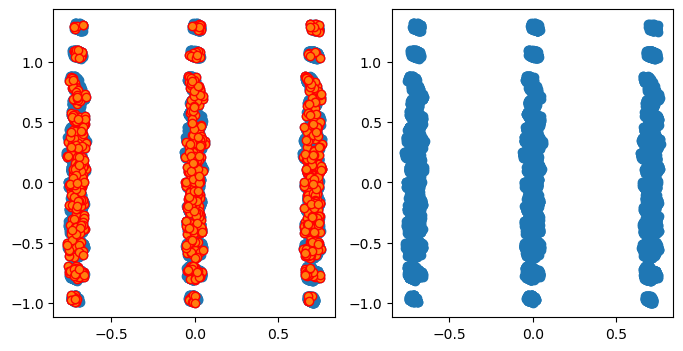

In [20]:
### n = 5
outliers_lof(train_pca, n = 5)

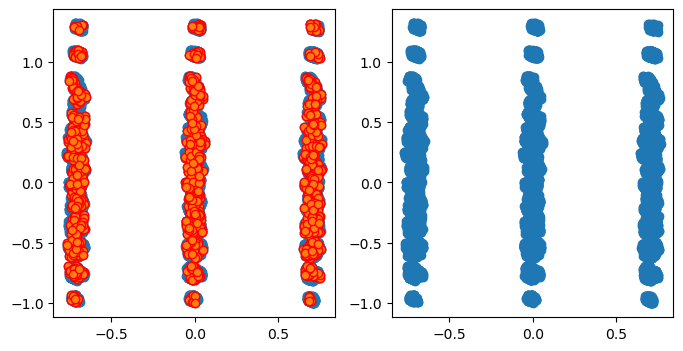

In [21]:
### taking n = 4
outliers_lof(train_pca, n = 4)

##### 3. DB scan for outliers

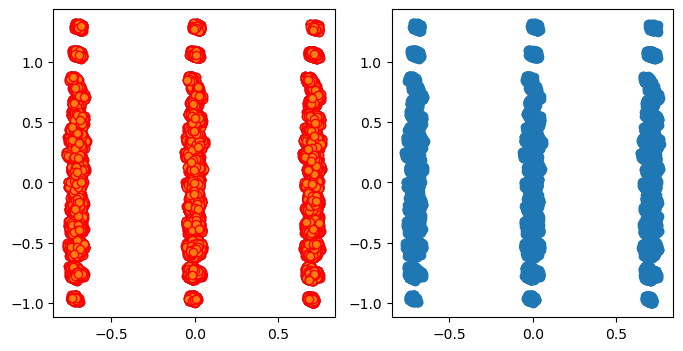

In [22]:
### taking eps as 1.2 (one from the clustering phase)
outliers_dbscan(train_pca, eps = 1.2)

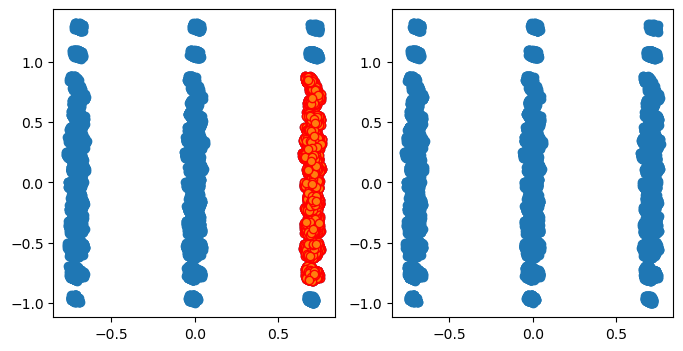

In [23]:
### taking eps = 0.1
outliers_dbscan(train_pca, eps = 0.1)

##### *********** Valid data *************

In [4]:
### setting up and loading the data 
valid_path = '../data/unsupervised_ready/valid.csv'
valid = load_data(valid_path)
valid.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,1,0,1,0,0,0,1,0,0,...,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,1,0,0,1,0,0,1,0,0,0,...,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0,0,0,0,0,0,0,0,1,0,...,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0,0,1,0,1,1,0,0,0,0,...,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,1,0,0,0,1,0,0,1,0,0,...,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352


In [5]:
### doing some verifications
check_nan_duplicates_shape(valid)

Shape : (10000, 33) 
Duplicates : 0 
Transaction_Type_Bank Transfer    0
Transaction_Type_Online           0
Transaction_Type_POS              0
Device_Type_Mobile                0
Device_Type_Tablet                0
Location_Mumbai                   0
Location_New York                 0
Location_Sydney                   0
Location_Tokyo                    0
Merchant_Category_Electronics     0
Merchant_Category_Groceries       0
Merchant_Category_Restaurants     0
Merchant_Category_Travel          0
Card_Type_Discover                0
Card_Type_Mastercard              0
Card_Type_Visa                    0
Authentication_Method_OTP         0
Authentication_Method_PIN         0
Authentication_Method_Password    0
Account_Balance                   0
IP_Address_Flag                   0
Previous_Fraudulent_Activity      0
Daily_Transaction_Count           0
Avg_Transaction_Amount_7d         0
Failed_Transaction_Count_7d       0
Card_Age                          0
Transaction_Distance       

In [6]:
### reducing the data to 2 dimensions
valid_pca = reduce_dimensions(valid)
check_shape(valid_pca)

(10000, 2)

##### 1. Isolation Forest

[-0.68649329 -0.68232575 -0.68079612 ... -0.42955287 -0.4291766
 -0.42892523]


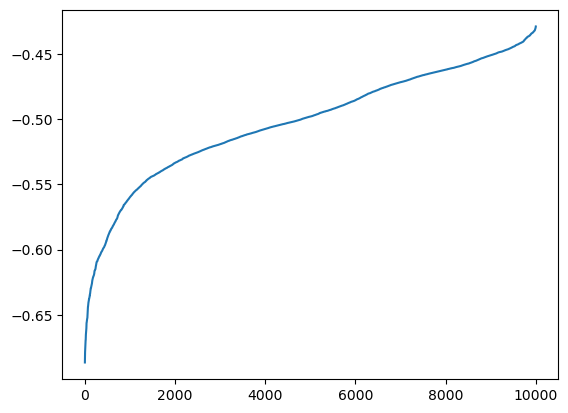

In [10]:
### finding the value of threshold
scores_valid = find_threshold(valid_pca)

In [11]:
### taking the threshold as -0.56 and finding the contamination
find_contamination(valid_pca, scores_valid, threshold = -0.56)

995
0.09950000000000003


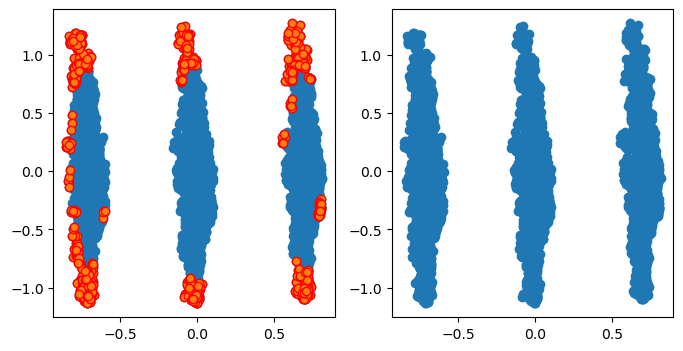

In [12]:
### plotting the anomalies using the Isolation forest and cutoff as 0.1 (round off)
outliers_isolation_forest(valid_pca, contamination = 0.1)

##### 2. Using the LOF

In [13]:
### for the lof, I considered n_neighbors as 5 and n = 4, algorithm = 'auto' and leaf_size = 30
### as for the local outliers we wanna detect wuth respect to the closest clusters rather than
### finding out the overall outliers

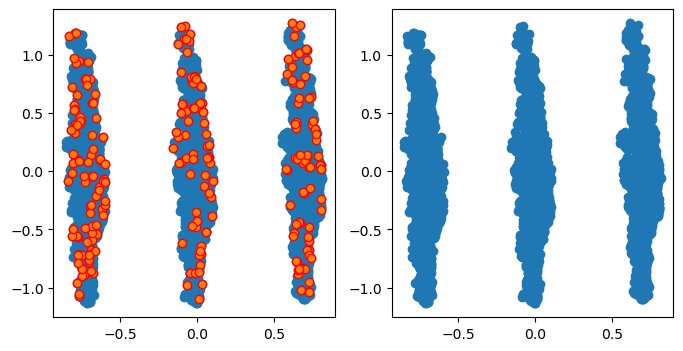

In [14]:
### taking n = 5
outliers_lof(valid_pca, n = 5)

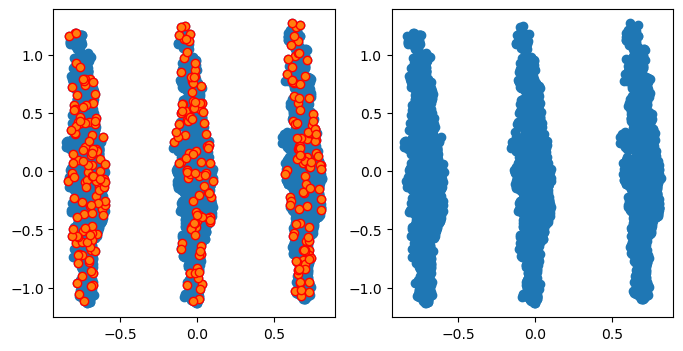

In [15]:
### taking the n = 4
outliers_lof(valid_pca, n = 4)

##### 3. DB Scan for outliers

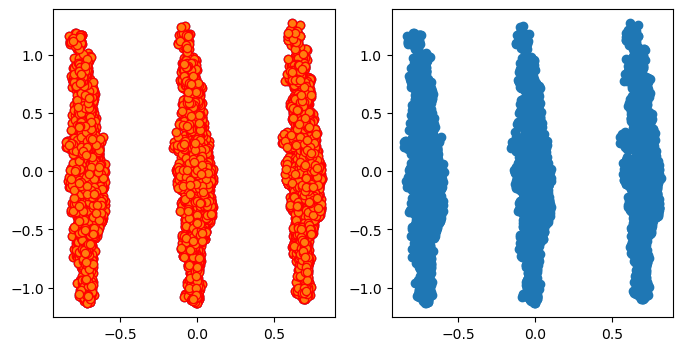

In [16]:
### taking eps = 1.3 (from the clustering part)
outliers_dbscan(valid_pca, eps = 1.3)

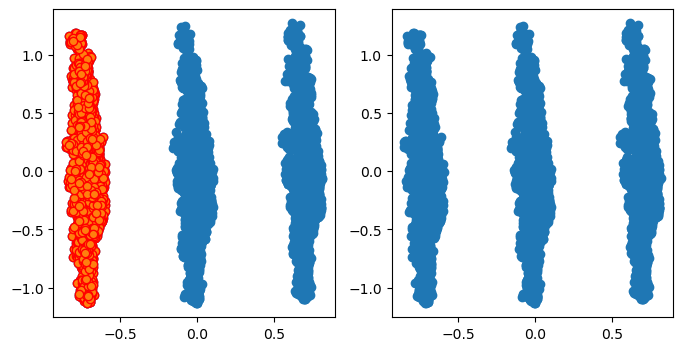

In [18]:
### taking the eps = 0.1
outliers_dbscan(valid_pca, eps = 0.1)